# Rainfall Cluster Analysis — DBSCAN / GMM

Clusters GPM IMERG 0.1° × 0.1° grid points into rainfall-based bins using **DBSCAN** or a **Gaussian Mixture Model (GMM)**.  
Three features are used: **latitude**, **longitude**, and **mean annual rainfall** (mm/year).

## 1 · Import Required Libraries

In [35]:
import netCDF4 as nc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime
import os
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.mixture import GaussianMixture

print("All libraries loaded successfully.")

All libraries loaded successfully.


## 2 · Configuration & Model Selection

Set all tunable parameters here before running the rest of the notebook.

In [36]:
# ── Path to the GPM IMERG NetCDF file ──────────────────────────────────────────
NC_FILE_PATH = r'G:\SM2RAIN-irrigation_Final\data\precipitation_data\GPM_IMERG_ludhiana_final_run.nc'


# ── Year range for computing multi-year average annual rainfall ────────────────
START_YEAR = 2015
END_YEAR   = 2025

# ── Number of desired clusters / bins ─────────────────────────────────────────
NUM_BINS = 5

# ── Clustering method: 'DBSCAN' or 'GMM' ─────────────────────────────────────
CLUSTERING_METHOD = 'GMM'   # <── change to 'DBSCAN' to switch

# ── DBSCAN hyper-parameters (only used when CLUSTERING_METHOD == 'DBSCAN') ────
DBSCAN_EPS         = 0.5   # neighbourhood radius in scaled-feature space
DBSCAN_MIN_SAMPLES = 3     # minimum points to form a core point

print(f"Clustering method : {CLUSTERING_METHOD}")
print(f"Number of bins    : {NUM_BINS}")
print(f"Year range        : {START_YEAR} – {END_YEAR}")
print(f"NetCDF file       : {NC_FILE_PATH}")

type_dates = "ludhiana" # "validate"

output_dir      = Path(rf'./GPM_classes_{type_dates}')
os.makedirs(output_dir, exist_ok = True)
output_filename = f'rainfall_classification_{NUM_BINS}_bins_{CLUSTERING_METHOD}.csv'
output_path     = output_dir / output_filename

print(output_path)


Clustering method : GMM
Number of bins    : 5
Year range        : 2015 – 2025
NetCDF file       : G:\SM2RAIN-irrigation_Final\data\precipitation_data\GPM_IMERG_ludhiana_final_run.nc
GPM_classes_ludhiana\rainfall_classification_5_bins_GMM.csv


## 3 · Load GPM IMERG NetCDF Data

In [37]:
nc_file = nc.Dataset(NC_FILE_PATH, 'r')

lat           = nc_file.variables['lat'][:]
lon           = nc_file.variables['lon'][:]
precipitation = nc_file.variables['precipitation'][:]
time_data     = nc_file.variables['date'][:]

# Decode date strings (format: DD-MM-YYYY) — same logic as identify.ipynb
dates = []
for i in range(time_data.shape[0]):
    date_str = b''.join(time_data[i]).decode('utf-8')
    dates.append(datetime.strptime(date_str, '%d-%m-%Y'))
dates = np.array(dates)

print("Dataset loaded successfully!")
print(f"  Spatial grid : {len(lat)} lat × {len(lon)} lon")
print(f"  Total points : {len(lat) * len(lon)}")
print(f"  Date range   : {dates[0].strftime('%Y-%m-%d')} → {dates[-1].strftime('%Y-%m-%d')}")

Dataset loaded successfully!
  Spatial grid : 12 lat × 12 lon
  Total points : 144
  Date range   : 2025-10-01 → 2025-09-30


## 4 · Compute Multi-Year Average Annual Rainfall per Grid Point

In [38]:
all_years     = np.array([d.year for d in dates])
years_in_range = np.unique(all_years[(all_years >= START_YEAR) & (all_years <= END_YEAR)])

if len(years_in_range) == 0:
    raise ValueError(f"No data found between {START_YEAR} and {END_YEAR}.")

print(f"Years included: {years_in_range}")

annual_totals_per_year = []
for year in years_in_range:
    yr_mask   = (all_years == year)
    yr_data   = precipitation[yr_mask, :, :]
    if np.ma.isMaskedArray(yr_data):
        yr_total = np.ma.sum(yr_data, axis=0)
    else:
        yr_total = np.sum(yr_data, axis=0)
    annual_totals_per_year.append(yr_total)

# Shape: (num_years, lat, lon)
annual_totals_stacked = np.ma.array(annual_totals_per_year)

# Mean across years → shape: (lat, lon)
yearly_avg_per_point = np.ma.mean(annual_totals_stacked, axis=0)

# Quick stats on valid values
_flat = yearly_avg_per_point.compressed() if np.ma.isMaskedArray(yearly_avg_per_point) \
        else yearly_avg_per_point.flatten()
print(f"Annual avg rainfall — min: {_flat.min():.2f}  max: {_flat.max():.2f}  mean: {_flat.mean():.2f} mm/year")

Years included: [2015 2016 2017 2018 2019 2020 2021 2022 2023 2024 2025]
Annual avg rainfall — min: 509.57  max: 923.23  mean: 664.57 mm/year


## 5 · Prepare Feature Matrix for Clustering

In [39]:
# Build full lat/lon grid matching the shape of yearly_avg_per_point
lat_grid, lon_grid = np.meshgrid(lat, lon, indexing='ij')  # (lat, lon)

# Flatten all three grids
lat_flat         = lat_grid.flatten().data if np.ma.isMaskedArray(lat_grid) else lat_grid.flatten()
lon_flat         = lon_grid.flatten().data if np.ma.isMaskedArray(lon_grid) else lon_grid.flatten()
rainfall_flat    = yearly_avg_per_point.flatten()

# Build valid-index mask (remove masked / fill-value cells)
if np.ma.isMaskedArray(rainfall_flat):
    if np.shape(rainfall_flat.mask) == ():          # scalar mask
        valid_indices = np.ones(len(rainfall_flat), dtype=bool) if not rainfall_flat.mask \
                        else np.zeros(len(rainfall_flat), dtype=bool)
    else:
        valid_indices = ~rainfall_flat.mask.flatten()
else:
    valid_indices = np.isfinite(rainfall_flat)
    if hasattr(nc_file.variables['precipitation'], '_FillValue'):
        fill_val = nc_file.variables['precipitation']._FillValue
        valid_indices &= (rainfall_flat != fill_val)

lat_valid      = np.asarray(lat_flat)[valid_indices]
lon_valid      = np.asarray(lon_flat)[valid_indices]
rainfall_valid = np.asarray(rainfall_flat)[valid_indices]

# Feature matrix: columns = [latitude, longitude, annual_avg_rainfall_mm]
X_raw = np.column_stack([lat_valid, lon_valid, rainfall_valid])

print(f"Feature matrix shape : {X_raw.shape}  (N points × 3 features)")
print(f"  lat    : {lat_valid.min():.3f} – {lat_valid.max():.3f}")
print(f"  lon    : {lon_valid.min():.3f} – {lon_valid.max():.3f}")
print(f"  rain   : {rainfall_valid.min():.2f} – {rainfall_valid.max():.2f} mm/yr")

Feature matrix shape : (144, 3)  (N points × 3 features)
  lat    : 29.950 – 31.050
  lon    : 74.950 – 76.050
  rain   : 509.57 – 923.23 mm/yr


## 6 · Scale Features

Standardise all three features to zero mean and unit variance so that lat/lon (degrees) and rainfall (mm/year) contribute equally.

In [40]:
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

print("Feature scaling complete (StandardScaler).")
print(f"  Scaled means : {X_scaled.mean(axis=0).round(6)}")
print(f"  Scaled stds  : {X_scaled.std(axis=0).round(6)}")

Feature scaling complete (StandardScaler).
  Scaled means : [-0. -0.  0.]
  Scaled stds  : [1. 1. 1.]


## 7 · Run Clustering (DBSCAN or GMM)

In [41]:
if CLUSTERING_METHOD == 'GMM':
    model  = GaussianMixture(n_components=NUM_BINS, covariance_type='full', random_state=42, n_init=5)
    model.fit(X_scaled)
    raw_labels = model.predict(X_scaled)          # integer labels 0 .. NUM_BINS-1
    noise_mask = np.zeros(len(raw_labels), dtype=bool)  # GMM has no noise concept
    print(f"GMM fitted with {NUM_BINS} components.")

elif CLUSTERING_METHOD == 'DBSCAN':
    model      = DBSCAN(eps=DBSCAN_EPS, min_samples=DBSCAN_MIN_SAMPLES)
    raw_labels = model.fit_predict(X_scaled)
    noise_mask = (raw_labels == -1)
    n_clusters = len(set(raw_labels) - {-1})
    print(f"DBSCAN found {n_clusters} clusters (eps={DBSCAN_EPS}, min_samples={DBSCAN_MIN_SAMPLES}).")
    print(f"  Noise points : {noise_mask.sum()} ({noise_mask.mean()*100:.1f}%)")

else:
    raise ValueError(f"Unknown CLUSTERING_METHOD '{CLUSTERING_METHOD}'. Use 'GMM' or 'DBSCAN'.")

unique_labels = sorted(set(raw_labels) - {-1})
print(f"Unique cluster labels (excl. noise): {unique_labels}")

GMM fitted with 5 components.
Unique cluster labels (excl. noise): [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]


## 8 · Map Cluster Labels → Bins Sorted by Mean Rainfall

Re-index labels so that **Bin 1 = driest** cluster and **Bin N = wettest**. DBSCAN noise points are assigned **Bin 0**.

In [42]:
# Compute mean rainfall per cluster label to determine sorting order
cluster_mean_rainfall = {}
for lbl in unique_labels:
    cluster_mean_rainfall[lbl] = rainfall_valid[raw_labels == lbl].mean()

# Sort labels by ascending mean rainfall
sorted_labels = sorted(unique_labels, key=lambda l: cluster_mean_rainfall[l])

# Map original label → 1-based bin number (Bin 1 = driest)
label_to_bin = {lbl: (rank + 1) for rank, lbl in enumerate(sorted_labels)}

# Assign final bins; noise → 0
bin_assignments = np.where(noise_mask, 0, np.vectorize(label_to_bin.get)(raw_labels))

# Summary table
print(f"\nBin assignment summary ({CLUSTERING_METHOD}):")
print("=" * 80)
print(f"{'Bin':<6} {'Rainfall Range (mm/year)':<35} {'Count':<10} {'Pct':>6}")
print("=" * 80)
for bn in range(1, len(sorted_labels) + 1):
    mask   = (bin_assignments == bn)
    vals   = rainfall_valid[mask]
    pct    = mask.sum() / len(bin_assignments) * 100
    print(f"Bin {bn:<3} [{vals.min():>8.2f} – {vals.max():>8.2f}]        {mask.sum():<10} {pct:>5.1f}%")
if noise_mask.any():
    nm = noise_mask.sum()
    print(f"Noise  (bin=0)                                      {nm:<10} {nm/len(bin_assignments)*100:>5.1f}%")
print("=" * 80)
print(f"Total grid cells: {len(bin_assignments)}")


Bin assignment summary (GMM):
Bin    Rainfall Range (mm/year)            Count         Pct
Bin 1   [  509.57 –   600.68]        26          18.1%
Bin 2   [  609.07 –   646.82]        13           9.0%
Bin 3   [  593.24 –   716.96]        39          27.1%
Bin 4   [  577.68 –   750.00]        37          25.7%
Bin 5   [  686.94 –   923.23]        29          20.1%
Total grid cells: 144


## 9 · Save Classification to CSV

In [43]:
# Build DataFrame in identical column order to identify.ipynb output
bin_classification = pd.DataFrame({
    'latitude'              : lat_valid,
    'longitude'             : lon_valid,
    'annual_avg_rainfall_mm': rainfall_valid,
    'bin'                   : bin_assignments,
    'grid_cell_index'       : np.arange(len(lat_valid)),
})

# Output path — saved alongside this notebook

bin_classification.to_csv(output_path, index=False)

print(f"\n{'='*80}")
print(f"Classification saved to : {output_path}")
print(f"Total records           : {len(bin_classification)}")
print(f"{'='*80}")
print("\nFirst 10 records:")
print(bin_classification.head(10).to_string(index=False))
print(f"{'='*80}")


Classification saved to : GPM_classes_ludhiana\rainfall_classification_5_bins_GMM.csv
Total records           : 144

First 10 records:
 latitude  longitude  annual_avg_rainfall_mm  bin  grid_cell_index
29.950001  74.949997              509.573639    1                0
29.950001  75.050003              515.600952    1                1
29.950001  75.150002              521.664978    1                2
29.950001  75.250000              537.412659    1                3
29.950001  75.349998              573.346802    1                4
29.950001  75.449997              617.907715    2                5
29.950001  75.550003              593.241272    3                6
29.950001  75.650002              603.882751    3                7
29.950001  75.750000              629.535889    3                8
29.950001  75.849998              657.930908    3                9


## 10 · Plot Clusters on a Spatial Map

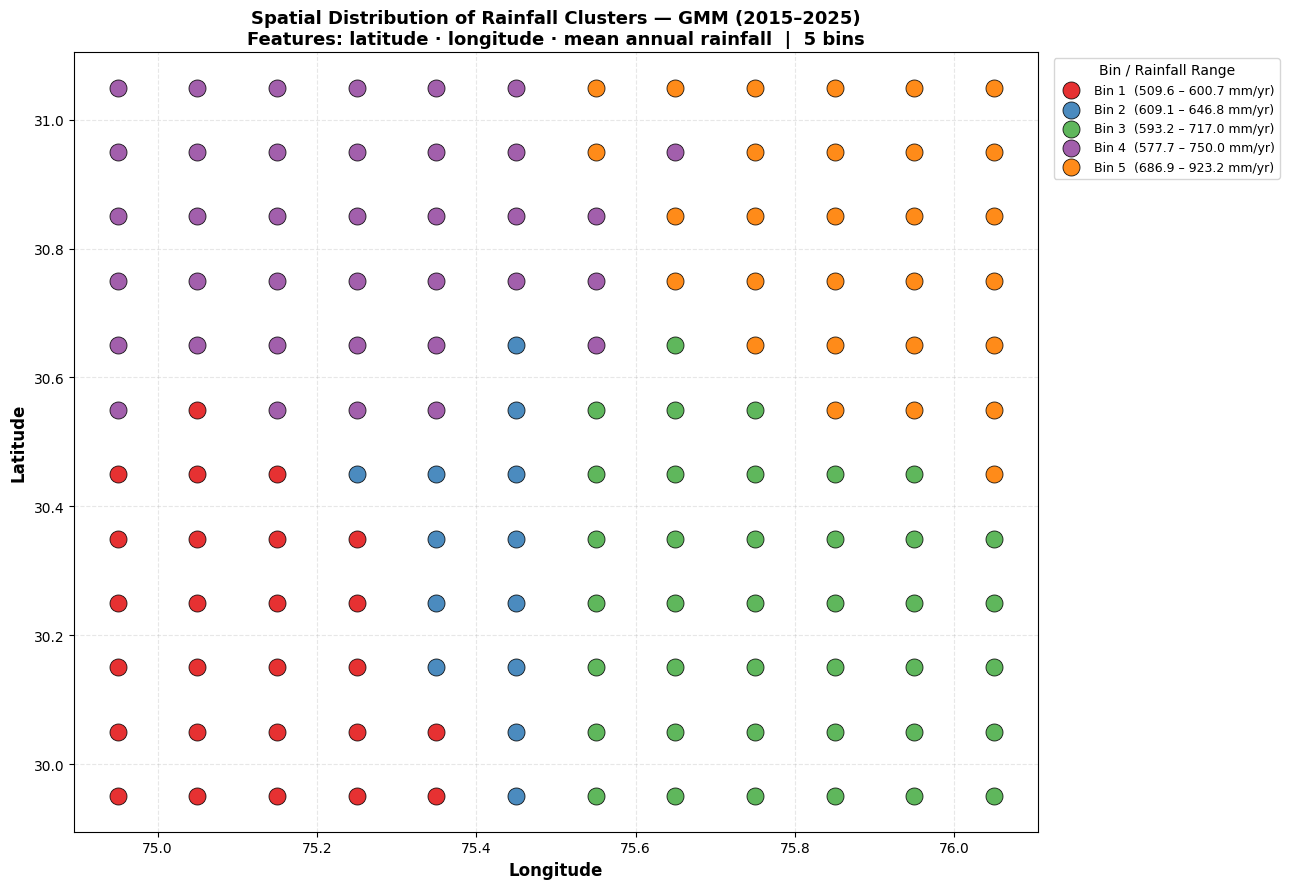

Map saved to: GPM_classes_ludhiana\images\rainfall_clusters_5_bins_GMM.png


In [44]:
distinct_colors = [
    '#e41a1c', '#377eb8', '#4daf4a', '#984ea3',
    '#ff7f00', '#a65628', '#f781bf', '#999999', '#ffff33',
]

fig, ax = plt.subplots(figsize=(13, 9))

# Plot DBSCAN noise points first (bin 0) if any
noise_df = bin_classification[bin_classification['bin'] == 0]
if not noise_df.empty:
    ax.scatter(noise_df['longitude'], noise_df['latitude'],
               color='lightgrey', label=f'Noise ({len(noise_df)} pts)',
               s=60, edgecolors='none', alpha=0.5)

# Plot each non-noise bin
all_bins = sorted(bin_classification[bin_classification['bin'] > 0]['bin'].unique())
for bn in all_bins:
    subset = bin_classification[bin_classification['bin'] == bn]
    lo = subset['annual_avg_rainfall_mm'].min()
    hi = subset['annual_avg_rainfall_mm'].max()
    color = distinct_colors[(bn - 1) % len(distinct_colors)]
    ax.scatter(
        subset['longitude'], subset['latitude'],
        color=color,
        label=f'Bin {bn}  ({lo:.1f} – {hi:.1f} mm/yr)',
        s=150, edgecolors='black', linewidths=0.6, alpha=0.9,
    )

ax.set_xlabel('Longitude', fontsize=12, fontweight='bold')
ax.set_ylabel('Latitude',  fontsize=12, fontweight='bold')
ax.set_title(
    f'Spatial Distribution of Rainfall Clusters — {CLUSTERING_METHOD} ({START_YEAR}–{END_YEAR})\n'
    f'Features: latitude · longitude · mean annual rainfall  |  {NUM_BINS} bins',
    fontsize=13, fontweight='bold',
)
ax.legend(title='Bin / Rainfall Range', loc='upper left', bbox_to_anchor=(1.01, 1), fontsize=9)
ax.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()

# Save the figure alongside the CSV
fig_path = output_dir /"images"/ f'rainfall_clusters_{NUM_BINS}_bins_{CLUSTERING_METHOD}.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Map saved to: {fig_path}")

## 11 · Per-Bin Summary Statistics

In [45]:
print("Per-Bin Summary Statistics")
print("=" * 80)

for bn in sorted(bin_classification['bin'].unique()):
    subset = bin_classification[bin_classification['bin'] == bn]
    label  = f"Noise" if bn == 0 else f"Bin {bn}"
    print(f"\n{label}:  {len(subset)} grid cells")
    print(f"  Rainfall : min={subset['annual_avg_rainfall_mm'].min():.2f}  "
          f"max={subset['annual_avg_rainfall_mm'].max():.2f}  "
          f"mean={subset['annual_avg_rainfall_mm'].mean():.2f} mm/yr")
    print(f"  Lat bbox : {subset['latitude'].min():.3f} – {subset['latitude'].max():.3f}")
    print(f"  Lon bbox : {subset['longitude'].min():.3f} – {subset['longitude'].max():.3f}")

print("\n" + "=" * 80)
print("OVERALL STATISTICS")
print("=" * 80)
print(f"  Max rainfall : {rainfall_valid.max():.2f} mm/yr")
print(f"  Min rainfall : {rainfall_valid.min():.2f} mm/yr")
print(f"  Mean rainfall: {rainfall_valid.mean():.2f} mm/yr")
print(f"  Total cells  : {len(bin_classification)}")
print("=" * 80)

# Close the NetCDF file
nc_file.close()
print("\nNetCDF file closed.")

Per-Bin Summary Statistics

Bin 1:  26 grid cells
  Rainfall : min=509.57  max=600.68  mean=549.94 mm/yr
  Lat bbox : 29.950 – 30.550
  Lon bbox : 74.950 – 75.350

Bin 2:  13 grid cells
  Rainfall : min=609.07  max=646.82  mean=629.09 mm/yr
  Lat bbox : 29.950 – 30.650
  Lon bbox : 75.250 – 75.450

Bin 3:  39 grid cells
  Rainfall : min=593.24  max=716.96  mean=662.81 mm/yr
  Lat bbox : 29.950 – 30.650
  Lon bbox : 75.550 – 76.050

Bin 4:  37 grid cells
  Rainfall : min=577.68  max=750.00  mean=671.95 mm/yr
  Lat bbox : 30.550 – 31.050
  Lon bbox : 74.950 – 75.650

Bin 5:  29 grid cells
  Rainfall : min=686.94  max=923.23  mean=776.21 mm/yr
  Lat bbox : 30.450 – 31.050
  Lon bbox : 75.550 – 76.050

OVERALL STATISTICS
  Max rainfall : 923.23 mm/yr
  Min rainfall : 509.57 mm/yr
  Mean rainfall: 664.57 mm/yr
  Total cells  : 144

NetCDF file closed.
